# Primer paso 
El primer paso es crearme una caja de herramientas de evaluación. Como tengo un problema de clases desbalanceadas (solo el 11.7% contrata el depósito), necesito una función de Python que me dé las métricas correctas y me dibuje gráficas para ver dónde se equivoca el modelo. 

In [ ]:
# Voy a importar las librerías necesarias para las métricas y los gráficos
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

def evaluar_modelo(y_real, y_pred, y_probabilidades, nombre_modelo="Modelo"):
    """
    Función para evaluar las predicciones de un modelo de clasificación.
    Muestra las métricas principales y dibuja la Matriz de Confusión y la Curva ROC.
    """
    print(f"Evaluación del modelo: '{nombre_modelo}'")
    
    # 1) Reporte de clasificación (Métricas de texto)
    print("Reporte de Clasificación:")
    print(classification_report(y_real, y_pred))
    
    # 2) Área bajo la curva ROC (ROC-AUC)
    auc = roc_auc_score(y_real, y_probabilidades)
    print(f"ROC-AUC Score: {auc:.4f}\n")
    
    # 3) Preparar la base para dibujar 2 gráficas juntas
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # GRÁFICA 1: Matriz de Confusión
    cm = confusion_matrix(y_real, y_pred)
    # Con seaborn (sns) la pinto de colores (mapa de calor)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title('Matriz de Confusión')
    ax[0].set_ylabel('Realidad (Lo que de verdad pasó)')
    ax[0].set_xlabel('Predicción (Lo que dijo el modelo)')
    ax[0].xaxis.set_ticklabels(['No Contrata (0)', 'Sí Contrata (1)'])
    ax[0].yaxis.set_ticklabels(['No Contrata (0)', 'Sí Contrata (1)'])
    
    # GRÁFICA 2: Curva ROC
    fpr, tpr, _ = roc_curve(y_real, y_probabilidades)
    ax[1].plot(fpr, tpr, color='orange', label=f'Curva ROC (AUC = {auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--') # La línea del azar
    ax[1].set_title('Curva ROC')
    ax[1].set_xlabel('Tasa de Falsos Positivos')
    ax[1].set_ylabel('Tasa de Verdaderos Positivos')
    ax[1].legend(loc="lower right")
    
    # Mostrar las gráficas
    plt.tight_layout()
    plt.show()

Esta función recibe las respuestas reales (y_real), lo que ha predicho mi modelo (y_pred), y la seguridad que tenía el modelo al predecirlo (y_probabilidades). Con eso, genra tres cosas muy importantes para nuestro banco:  

1. El ```classification_report``` (Las métricas clave)
En lugar de decirme solo que ha acertado "el 90% de las veces", este reporte me desglosará dos conceptos críticos para la clase "1", la gente que contrata:

    - Precision: De todos los clientes a los que el modelo propuso llamar, ¿cuántos contrataron de verdad? Si es baja, el banco estará perdiendo tiempo haciendo llamadas inútiles.

    - Recall (Exhaustividad): De todos los clientes que en la vida real querían contratar, ¿cuántos logró detectar el modelo? Si es baja, el banco estará perdiendo dinero por no llamar a gente que estaría dispuesta a comprar.

    - F1-Score: Es una nota media entre Precision y Recall. Será la métrica estrella de la función.

2. La matriz de confusión  
El código usa ```seaborn```para dibujar un cuadrado de 4 casillas de color. Me permitirá ver exactamente el tipo de erro que comete el modelo:
    - Verdaderos positivos (abajo-derecha): EL MEJOR. Si el modelo dijo que contrataría y el cliente contrató.
    - Falsos positivos (arriba-derecha): Falsa alarma. Si el modelo me hizo llamar a alguien que luego dijo que NO contratará.
    - Falsos negativos (abajo-izquierda): EL PEOR ERROR. El modelo dijo que no le llame, pero ese cliente sí quería contratar, y perdemos esa oportunidad.
    - Verdaderos negativos (arriba-izquierda): Ahorro de llamadas. Si el modelo me dijo que no intente llamar a alguien que efectivamente no habría contratado.

3. La curva ROC y el AUC  
Es un gráfico que nos va a mostrar cómo de bueno es el modelo separando a los que contratan de los que no. 
    - La línea azul punteada diagonal representa un modelo que tira azar (área del 0.50)
    - La línea naranja es mi modelo en evaluación. Cuanto más se aleje hacia la esquina de arriba-izquierda, mejor será. Si el área (que es el AUC) se acerca a 1.0, tengo un súper modelo.

Esto es lo primero que hago porque ahora, sea cual sea el algoritmo que entrenemos después (Regresión Logística, Random Forest, etc.), solo tendré que escribir evaluar_modelo(que sea) y me va a devolver un informe detallado y visual en un segundo. 

# Paso previo a los baselines
Enriquecer la base de datos antes de los baselines, le añado a los modelos de clasificación una columna nueva (segmento) con mucho poder predictivo. 

In [ ]:
'''
Cuando tenga mis datos divididos (por ejemplo en X_train y X_test) que ya les quitó Claudia la 
variable objetivo (y) y la duración debo ejecutar esto:
'''
import joblib

# Cargo los joblib de C: escalador y modelo de clustering (K-Means)
scaler = joblib.load('scaler_segmentacion.pkl')
kmeans = joblib.load('kmeans_segmentacion.pkl')

# Escalo TODOS los datos de entrenamiento y test
# (!)Solo uso transform en los dos, porque el scaler ya se entrenó antes
X_train_escalado = scaler.transform(X_train)
X_test_escalado = scaler.transform(X_test)

# Predecir el cluster para todos los clientes y se añade como columna
X_train['segmento'] = kmeans.predict(X_train_escalado)
X_test['segmento'] = kmeans.predict(X_test_escalado)

# Para ver si quedó bien...
display(X_train.head()) # Este X_train nuevo es + inteligente.

A partir de aquí, ya empiezo a entrenar la RL, RF y el XGBoost. 

# Segundo paso  
Elsegundo va a ser crearme los Modelos Base o Baselines. Serán los modelos de referencia. El primer intento sin optimizar nada, para poner un listón inicial que luego mejoraré y ajustaré en fase 3, la de superar a estos baselines.
Voy a empezar con 3 algoritmos que hemos usado en clase, muy utilizados para datos tabulares como los del banco.

Truco del almendruco: ```class_weight='balanced'``` 
Como C descubrió que estaba la clase desbalanceada (11,7% contrata), voy a usar el parámetro de arriba para que el algortimo clasifique como muy rara la clase 1 (los que contratan) para que penalice mucho más si se equivoca con este grupo. 

In [ ]:
'''
Como aún no tengo los datos limpios de M, voy a añadir unas líneas para generar datos de mentira,
que imiten el problema del banco (1000 clientes, donde solo el 12% casi contrata). Así probaré el 
código y ver si 'funciona la función'. x)
'''
# Importar librerías para generar datos falsos
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

print("Cargando datos...")
# SIMULACIÓN DE DATOS (Mientras llega la parte de M) Esto lo borraré cuando tenga los datos de M.
# Meteré sus variables reales (X_train_M, y_train_M) y me dará los resultados buenos y reales.
# Creo 1000 clientes falsos, con un 12% de contrataciones (weights=[0.88, 0.12])
X_dummy, y_dummy = make_classification(n_samples=1000, n_features=15, 
                                       weights=[0.88, 0.12], random_state=42)

# Dividimos en Train y Test asegurando que se mantiene la proporción del 12% (stratify)
X_train, X_test, y_train, y_test = train_test_split(X_dummy, y_dummy, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y_dummy)
print("Datos listos para entrenar.")

Cargando datos...
Datos listos para entrenar.


Iniciando comparativa de modelos Baseline...

---------------
Evaluando: Regresión Logística
---------------
Evaluación del modelo: 'Regresión Logística'
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.86      0.92       175
           1       0.48      0.88      0.62        25

    accuracy                           0.86       200
   macro avg       0.73      0.87      0.77       200
weighted avg       0.92      0.86      0.88       200

ROC-AUC Score: 0.9362



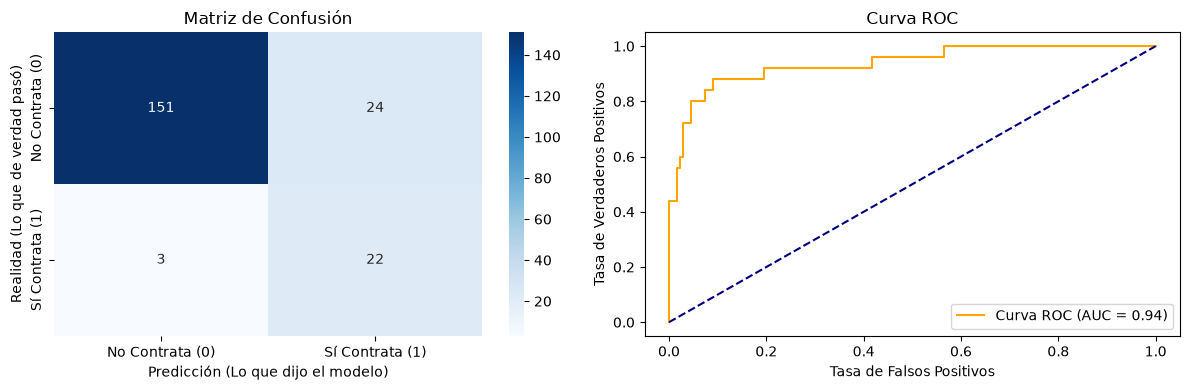


---------------
Evaluando: Random Forest
---------------
Evaluación del modelo: 'Random Forest'
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       175
           1       0.87      0.80      0.83        25

    accuracy                           0.96       200
   macro avg       0.92      0.89      0.91       200
weighted avg       0.96      0.96      0.96       200

ROC-AUC Score: 0.9515



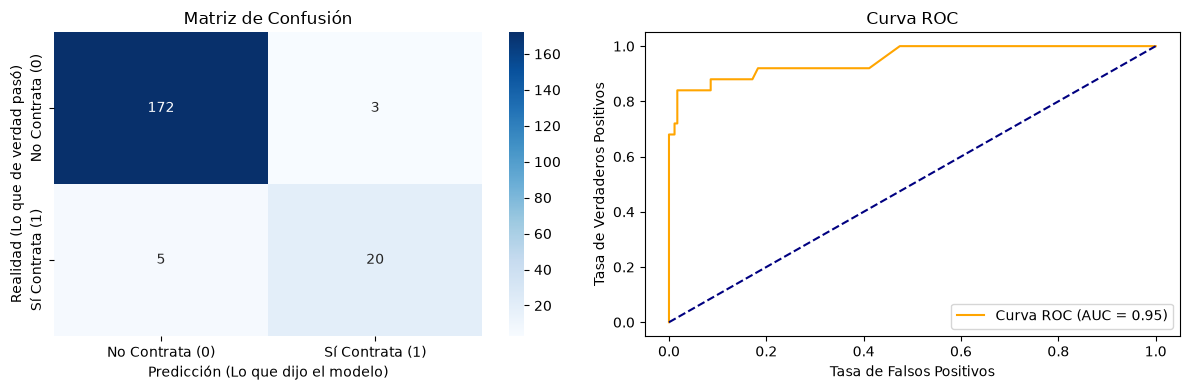


---------------
Evaluando: XGBoost
---------------
Evaluación del modelo: 'XGBoost'
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       175
           1       1.00      0.68      0.81        25

    accuracy                           0.96       200
   macro avg       0.98      0.84      0.89       200
weighted avg       0.96      0.96      0.96       200

ROC-AUC Score: 0.9173



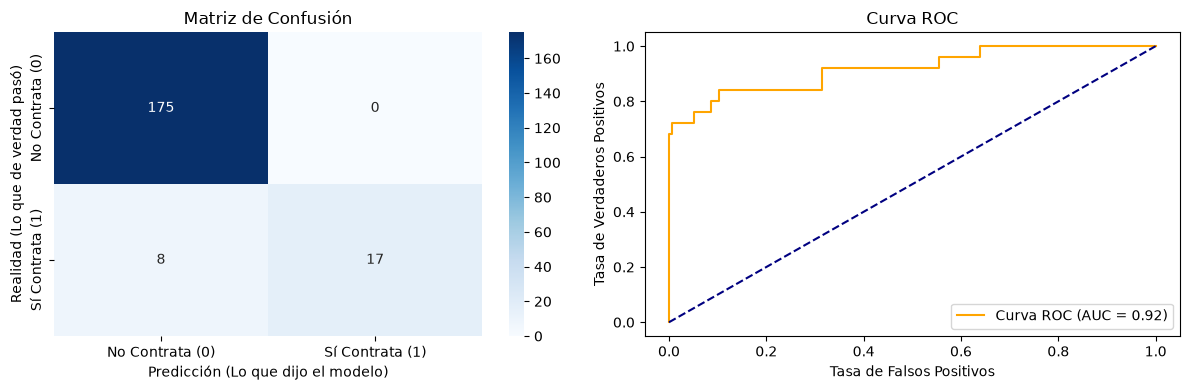

In [ ]:
'''
En esta única celda de código voy a meter todo el código de la comparativa baseline de los 3 modelos.
Importar modelos. Voy a usar 3 a priori: regresión, RF y XGBoost
'''
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import numpy as np
print("Iniciando comparativa de modelos Baseline...")

'''
Modelo 3: XGBoost (con el que mejor me salió el TC de Kaggle) no tiene class_weight! en su lugar 
utiliza scale_pos_weight, parámetro que le dice cuántas veces más grande es la clase mayoritaria
(los NO respecto a los SÍ) 
Calculamos el peso para XGBoost (para 'balancear la balanza' matemáticamente, contar cuántos 0 (No)
y 1 (Sí) hay en el entrenamiento. Después en XGBoost la fórmula es: negativos/positivos (lo hago junto):
'''
peso_clases = np.sum(y_train == 0) / np.sum(y_train == 1)

# Guardo en un diccionario los 3 modelos listos para competir
modelos_base = {
    "Regresión Logística": LogisticRegression(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(scale_pos_weight=peso_clases, random_state=42, eval_metric='logloss') # Métrica recomendada para clasificación
}

''' 
Voy a meter los 3 en un bucle para ahorrar código y evitar errores como mezclar predicciones de modelos
distintos en las evaluaciones... Además lo hago de una:
'''
for nombre, modelo in modelos_base.items():
    print(f"\n{'-'*25}")
    print(f"Evaluando: {nombre}")
    print(f"{'-'*25}")
    
    # Entrenar
    modelo.fit(X_train, y_train)
    
    # Predecir
    predicciones = modelo.predict(X_test)
    probabilidades = modelo.predict_proba(X_test)[:, 1]
    
    # Dibujar
    evaluar_modelo(y_test, predicciones, probabilidades, nombre_modelo=nombre)
# El ganador tendra el mejor F1-Score y AUC

Interpretación ¡de Random Forest solo! (lo dejo como ejemplo): Se ha entrenado el RF muy rápido; aparece el Reporte de clasificación muy detallado y me fijo en la fila del 1(los que contratan). Veo la precisión, el recall y el F1-Score. También aparecieron perfectamente los dos gráficas: la matriz de confusión que me muestra cuántos falsos positivos y falsos negativos ha cometido en esta simulación y la curva ROC me ha dado la puntuación AUC. 

- 172 (Verdaderos Negativos): El modelo RF detectó a 172 personas que no iban a comprar y acertó. Son 172 llamadas inútiles que nos ahorramos.

- 20 (Verdaderos Positivos): El modelo detectó a 20 personas que sí querían contratar, y el banco cerró esas ventas.

- 3 (Falsos Positivos): El modelo falló diciendo que 3 personas iban a contratar, pero dijeron que no. Apenas 3 llamadas perdidas. Coste súper bajo.

- 5 (Falsos Negativos): El modelo dejó escapar a 5 personas que sí habrían contratado. Es el único punto de mejora, pero equivocarse solo 5 veces está perfe. 

Un AUC de **0.95** significa que el modelo roza la perfección a la hora de ordenar a los clientes de "más probable a menos probable" de contratar. Y un F1-Score de 0.83 en un problema desbalanceado (donde lo normal es sacar notas de 0.40 o 0.50) es una nota sobresaliente.

# Optimización
En esta tercera parte, el objetivo es el de exprimir los modelos al máximo para buscar la configuración perfecta del algoritmo. Para ello, voy a utilizar GridSearchCV, para probar distintas combinaciones y obtiene el mejor F1-Score.

Evalúo los tres, me quedo con el que tenga mejor F1-Score y mejor AUC en la gráfica de evaluación, y a ese ganador le aplico el GridSearchCV para la entrega final. Cada modelo se optimiza de forma distinta. Como en el ejemplo ha ganado RF, voy a suponer que ganará después también, una vez que tenga el trabajo de Marta. Voy a practicar optimizar XGBoost también porque suele ser el mejor.

Iniciando la optimización de hiperparámetros...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

¡Optimización terminada!
Mejores hiperparámetros encontrados: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Evaluación del modelo: 'Random Forest (Optimizado)'
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       175
           1       0.87      0.80      0.83        25

    accuracy                           0.96       200
   macro avg       0.92      0.89      0.91       200
weighted avg       0.96      0.96      0.96       200

ROC-AUC Score: 0.9515



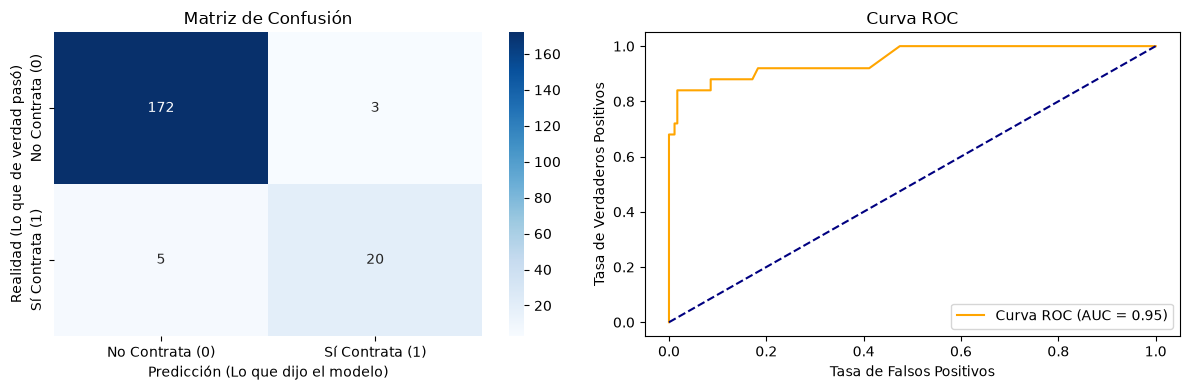

In [ ]:
# Importo la herramienta de búsqueda en cuadrícula
from sklearn.model_selection import GridSearchCV

print("Optimizando el modelo ganador (Random Forest)...")

# -> Defino los hiperparámetros
parametros_rf = {
    'n_estimators': [100, 200, 300], # nº árboles
    'max_depth': [5, 10, None], # None significa que los árboles crecen sin límite (prof. max. árboles)
    'min_samples_split': [2, 5, 10] # min de datos para seguir dividiendo
}

# De nuevo instancio el RF base
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# -> Configurar el GridSearchCV
# scoring='f1' para obligar al modelo a buscar la mejor nota en esa métrica
grid_search = GridSearchCV(estimator=rf_base, 
                           param_grid=parametros_rf, 
                           scoring='f1',  
                           cv=5, # Validación cruzada de 5 particiones
                           n_jobs=-1, # Para usar todos los procesadores
                           verbose=2) # Mensajes

# -> Entrenamos (lo q tarda)
grid_search.fit(X_train, y_train)

# -> Resultados de la optimización
print("\n¡Optimización terminada!")
print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")

# Guardo el mejor modelo
mejor_rf = grid_search.best_estimator_

# Evalúo de nuevo este nuevo modelón optimizado
predicciones_mejor = mejor_rf.predict(X_test)
probabilidades_mejor = mejor_rf.predict_proba(X_test)[:, 1]

evaluar_modelo(y_test, predicciones_mejor, probabilidades_mejor, nombre_modelo="Random Forest (Optimizado)")

Análisis optimización: me salen iguales números que sin optimizar (el baseline). Es porque le he puesto los hiperparámetros que salen por defecto: none, 2, 100. Y se ha quedado con ellos después de probar diferentes combinaciones. Esto pasa porque los datos falsos son matemñaticamente perfectos. (Ya salía un AUC de 0.95...) El modelo ya estaba muy arriba, porque los datos simulados son tan fáciles de predecir que no hay margen de mejora.  
Cuando M me pase los datos reales, sí que va a haber ruido.

In [ ]:
'''En XGBoost, las tuercas clave para mejorar el F1-Score sin que el modelo memorice los datos 
(overfitting) son estas:
'''
parametros_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2], # Qué tan rápido aprende en cada paso
    'max_depth': [3, 5, 7],            # Mejor mantener los árboles bajitos
    'subsample': [0.8, 1.0]            # Usa solo el 80% de los datos en cada árbol para dar variedad
}